In [ ]:
# Copyright (c) Microsoft Corporation.
# Licensed under the MIT License.

# -*- coding: utf-8 -*-

In [15]:
"""Notebook demonstrating transfer learning capability of the
the Deep Q-learning agent trained and evaluated on the chain
 environment of various sizes.

NOTE: You can run this `.py`-notebook directly from VSCode.
You can also generate a traditional Jupyter Notebook
using the VSCode command `Export Currenty Python File As Jupyter Notebook`.
"""

'Notebook demonstrating transfer learning capability of the\nthe Deep Q-learning agent trained and evaluated on the chain\n environment of various sizes.\n\nNOTE: You can run this `.py`-notebook directly from VSCode.\nYou can also generate a traditional Jupyter Notebook\nusing the VSCode command `Export Currenty Python File As Jupyter Notebook`.\n'

In [1]:
import os
import sys
sys.path.append("/source/cyberbattle") 

import logging
import gymnasium as gym
import torch

import cyberbattle.agents.baseline.learner as learner
import cyberbattle.agents.baseline.plotting as p
import cyberbattle.agents.baseline.agent_wrapper as w
import cyberbattle.agents.baseline.agent_dql as dqla
from cyberbattle.agents.baseline.agent_wrapper import Verbosity
import cyberbattle.agents.baseline.agent_randomcredlookup as rca
import importlib
import cyberbattle._env.cyberbattle_env as cyberbattle_env
import cyberbattle._env.cyberbattle_chain as cyberbattle_chain

importlib.reload(learner)
importlib.reload(cyberbattle_env)
importlib.reload(cyberbattle_chain)

logging.basicConfig(stream=sys.stdout, level=logging.ERROR, format="%(levelname)s: %(message)s")

%matplotlib inline

In [2]:
torch.cuda.is_available()

False

In [ ]:
# To run once
# import plotly.io as pio
# pio.orca.config.use_xvfb = True
# pio.orca.config.save()

In [2]:
cyberbattlechain_4 = gym.make("CyberBattleChain-v0", size=4, attacker_goal=cyberbattle_env.AttackerGoal(own_atleast_percent=1.0)).unwrapped
cyberbattlechain_10 = gym.make("CyberBattleChain-v0", size=10, attacker_goal=cyberbattle_env.AttackerGoal(own_atleast_percent=1.0)).unwrapped
cyberbattlechain_20 = gym.make("CyberBattleChain-v0", size=20, attacker_goal=cyberbattle_env.AttackerGoal(own_atleast_percent=1.0)).unwrapped

assert isinstance(cyberbattlechain_4, cyberbattle_env.CyberBattleEnv)
assert isinstance(cyberbattlechain_10, cyberbattle_env.CyberBattleEnv)
assert isinstance(cyberbattlechain_20, cyberbattle_env.CyberBattleEnv)

ep = w.EnvironmentBounds.of_identifiers(maximum_total_credentials=22, maximum_node_count=22, identifiers=cyberbattlechain_10.identifiers)

In [3]:
iteration_count = 9000
training_episode_count = 50
eval_episode_count = 10
plots_dir = "output/images"

In [4]:
os.makedirs(plots_dir, exist_ok=True)

###### DQL
Learning with: episode_count=50,iteration_count=9000,ϵ=0.9,ϵ_min=0.1, ϵ_expdecay=5000,γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10
  ## Episode: 1/50 'DQL' ϵ=0.9000, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 4|reward:   14.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 4|reward:   14.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 1|Iteration 8|reward:   16.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 1|Iteration 8|reward:   16.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 15|reward:   20.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 15|reward:   20.0|last_reward_at:   15|Elapsed Time: 0:00:00||
Episode 1|Iteration 32|reward:  120.0|last_reward_at:   15|Elapsed Time: 0:00:00||
Episode 1|Iteration 32|reward:  120.0|last_reward_at:   32|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  131.0|last_reward_at:   32|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  131.0|last_reward_at:   34|Elapsed Time: 0:00:00||
Episode 1|

  Episode 1 ended at t=1089 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 7/228 (0.03)
    explore-remote: 18/307 (0.06)
    explore-connect: 3/352 (0.01)
    exploit-local: 14/53 (0.21)
    exploit-remote: 1/18 (0.05)
    exploit-connect: 8/80 (0.09)
  exploit deflected to exploration: 13
  ## Episode: 2/50 'DQL' ϵ=0.7436, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 2|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 3|reward:   14.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 3|reward:   14.0|last_reward_at:    3|Elapsed Time: 0:00:00||
Episode 2|Iteration 4|reward:   18.0|last_reward_at:    3|Elapsed Time: 0:00:00||
Episode 2|Iteration 4|reward:   18.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 2|Iteration 7|reward:   20.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 2|Iteration 7|reward:   20.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:  120.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:  120.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 9|reward:  131.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 9|reward:  131.0|last_reward_at:    9|Elapsed Time: 0:00:00||
Episode 2|Iterat

  Episode 2 ended at t=221 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 4/33 (0.11)
    explore-remote: 15/41 (0.27)
    explore-connect: 1/60 (0.02)
    exploit-local: 14/2 (0.88)
    exploit-remote: 0/0 (NaN)
    exploit-connect: 10/41 (0.20)
  exploit deflected to exploration: 3
  ## Episode: 3/50 'DQL' ϵ=0.7157, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


...

  Episode 48 ended at t=51 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 3/3 (0.50)
    explore-remote: 3/3 (0.50)
    explore-connect: 0/7 (0.00)
    exploit-local: 11/0 (1.00)
    exploit-remote: 2/5 (0.29)
    exploit-connect: 11/3 (0.79)
  exploit deflected to exploration: 0
  ## Episode: 49/50 'DQL' ϵ=0.2892, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 49|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 49|Iteration 1|reward:   14.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 49|Iteration 1|reward:   14.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 49|Iteration 2|reward:  114.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 49|Iteration 2|reward:  114.0|last_reward_at:    2|Elapsed Time: 0:00:00||
Episode 49|Iteration 4|reward:  128.0|last_reward_at:    2|Elapsed Time: 0:00:00||
Episode 49|Iteration 4|reward:  128.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 49|Iteration 5|reward:  130.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 49|Iteration 5|reward:  130.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 49|Iteration 8|reward:  130.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 49|Iteration 10|reward:  132.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 49|Iteration 10|reward:  132.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Ep

  Episode 49 ended at t=92 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 1/8 (0.11)
    explore-remote: 4/7 (0.36)
    explore-connect: 0/12 (0.00)
    exploit-local: 11/3 (0.79)
    exploit-remote: 1/6 (0.14)
    exploit-connect: 11/28 (0.28)
  exploit deflected to exploration: 0
  ## Episode: 50/50 'DQL' ϵ=0.2858, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 50|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 50|Iteration 1|reward:   14.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 50|Iteration 1|reward:   14.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 50|Iteration 3|reward:  114.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 50|Iteration 3|reward:  114.0|last_reward_at:    3|Elapsed Time: 0:00:00||
Episode 50|Iteration 4|reward:  128.0|last_reward_at:    3|Elapsed Time: 0:00:00||
Episode 50|Iteration 4|reward:  128.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 50|Iteration 5|reward:  134.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 50|Iteration 5|reward:  134.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 50|Iteration 8|reward:  134.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 50|Iteration 11|reward:  134.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Episode 50|Iteration 12|reward:  136.0|last_reward_at:    5|Elapsed Time: 0:00:00||
Ep

  Episode 50 ended at t=171 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 0/7 (0.00)
    explore-remote: 1/17 (0.06)
    explore-connect: 1/23 (0.04)
    exploit-local: 12/1 (0.92)
    exploit-remote: 3/30 (0.09)
    exploit-connect: 10/66 (0.13)
  exploit deflected to exploration: 0
simulation ended


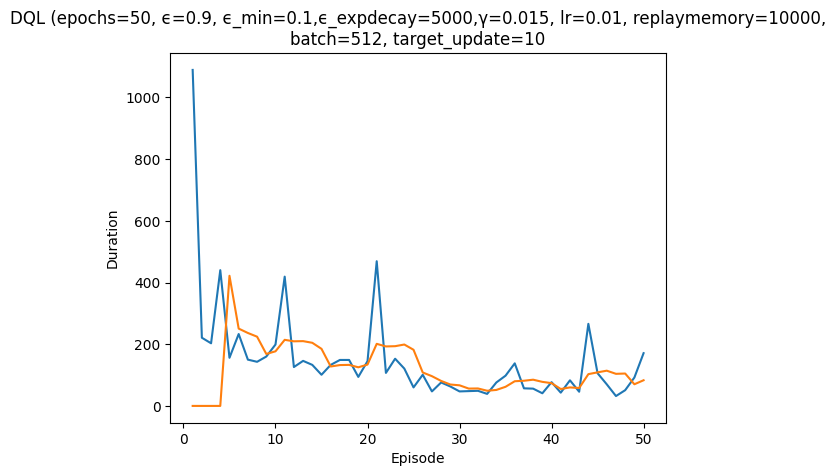

In [12]:
# Run Deep Q-learning
# 0.015
best_dqn_learning_run_10 = learner.epsilon_greedy_search(
    cyberbattle_gym_env=cyberbattlechain_10,
    environment_properties=ep,
    learner=dqla.DeepQLearnerPolicy(ep=ep, gamma=0.015, replay_memory_size=10000, target_update=10, batch_size=512, learning_rate=0.01),  # torch default is 1e-2
    episode_count=training_episode_count,
    iteration_count=iteration_count,
    epsilon=0.90,
    render=False,
    # epsilon_multdecay=0.75,  # 0.999,
    epsilon_exponential_decay=5000,  # 10000
    epsilon_minimum=0.10,
    verbosity=Verbosity.Quiet,
    title="DQL",
)

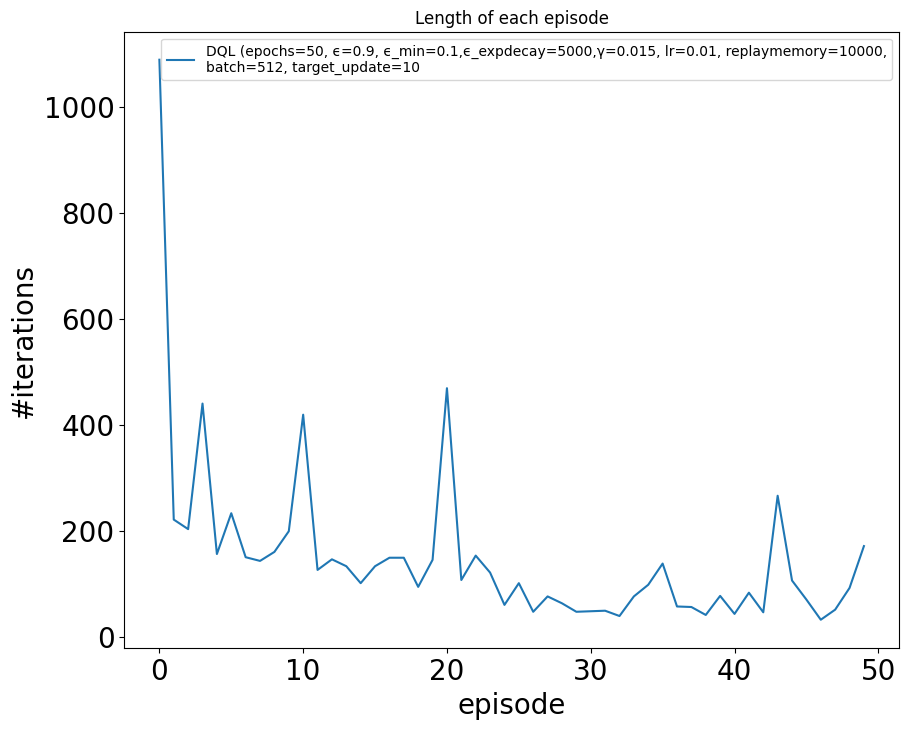

In [13]:
p.plot_episodes_length([best_dqn_learning_run_10])

In [4]:
if not os.path.exists("images"):
    os.mkdir("images")

In [ ]:
dql_exploit_run = learner.epsilon_greedy_search(
    cyberbattlechain_10,
    ep,
    learner=best_dqn_learning_run_10["learner"],
    episode_count=eval_episode_count,
    iteration_count=iteration_count,
    epsilon=0.0,  # 0.35,
    render=False,
    render_last_episode_rewards_to=os.path.join(plots_dir, "dql_transfer-chain10"),
    title="Exploiting DQL",
    verbosity=Verbosity.Quiet,
)

In [ ]:
random_run = learner.epsilon_greedy_search(
    cyberbattlechain_10,
    ep,
    learner=learner.RandomPolicy(),
    episode_count=eval_episode_count,
    iteration_count=iteration_count,
    epsilon=1.0,  # purely random
    render=False,
    verbosity=Verbosity.Quiet,
    title="Random search",
)

In [ ]:
# Plot averaged cumulative rewards for DQL vs Random vs DQL-Exploit
themodel = dqla.CyberBattleStateActionModel(ep)
p.plot_averaged_cummulative_rewards(
    all_runs=[best_dqn_learning_run_10, random_run, dql_exploit_run],
    title=f"Benchmark -- max_nodes={ep.maximum_node_count}, episodes={eval_episode_count},\n"
    f"State: {[f.name() for f in themodel.state_space.feature_selection]} "
    f"({len(themodel.state_space.feature_selection)}\n"
    f"Action: abstract_action ({themodel.action_space.flat_size()})",
)

In [ ]:
# plot cumulative rewards for all episodes
p.plot_all_episodes(best_dqn_learning_run_10)


##################################################

In [ ]:
best_dqn_4 = learner.epsilon_greedy_search(
    cyberbattle_gym_env=cyberbattlechain_4,
    environment_properties=ep,
    learner=dqla.DeepQLearnerPolicy(ep=ep, gamma=0.15, replay_memory_size=10000, target_update=5, batch_size=256, learning_rate=0.01),
    episode_count=training_episode_count,
    iteration_count=iteration_count,
    epsilon=0.90,
    render=False,
    epsilon_exponential_decay=5000,
    epsilon_minimum=0.10,
    verbosity=Verbosity.Quiet,
    title="DQL",
)

In [5]:
import agents.temp as tmp

import pickle

load = True
if load:
    with open("drql2.pkl", "rb") as f:
        drql_learner = pickle.load(f)
else:
    with open("drql2.pkl", "wb") as f:
        pickle.dump(drql_run["learner"], f)

In [6]:
trained_learner = {
    "learner": drql_learner,
    "trained_on": 'ToyCTF'
}

In [16]:
print(drql_learner)

In [7]:
learner.transfer_learning_evaluation(
    environment_properties=ep,
    trained_learner=trained_learner,
    eval_env=cyberbattlechain_4,
    eval_epsilon=0.0,  # alternate with exploration to help generalization to bigger network
    eval_episode_count=3,
    iteration_count=500,
    benchmark_policy=rca.CredentialCacheExploiter(),
    benchmark_training_args={"epsilon": 0.90, "epsilon_exponential_decay": 10000, "epsilon_minimum": 0.10, "title": "Credential lookups (ϵ-greedy)"},
)
"""
learner.transfer_learning_evaluation(
    environment_properties=ep,
    trained_learner=best_dqn_4,
    eval_env=cyberbattlechain_10,
    eval_epsilon=0.0,  # exploit Q-matrix only
    eval_episode_count=eval_episode_count,
    iteration_count=iteration_count,
    benchmark_policy=rca.CredentialCacheExploiter(),
    benchmark_training_args={"epsilon": 0.90, "epsilon_exponential_decay": 10000, "epsilon_minimum": 0.10, "title": "Credential lookups (ϵ-greedy)"},
)
"""

###### One shot on CyberBattleChain-4 - Trained on ToyCTF
Learning with: episode_count=3,iteration_count=500,ϵ=0.0,ϵ_min=0.0, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10
  ## Episode: 1/3 'One shot on CyberBattleChain-4 - Trained on ToyCTF' ϵ=0.0000, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
/source/agents/temp.py:486: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  state_batch = torch.tensor(states_to_consider).to(device)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x46 and 48x1024)

In [8]:
learner.transfer_learning_evaluation(
    environment_properties=ep,
    trained_learner=best_dqn_4,
    eval_env=cyberbattlechain_20,
    eval_epsilon=0.0,  # exploit Q-matrix only
    eval_episode_count=eval_episode_count,
    iteration_count=iteration_count,
    benchmark_policy=rca.CredentialCacheExploiter(),
    benchmark_training_args={"epsilon": 0.90, "epsilon_exponential_decay": 10000, "epsilon_minimum": 0.10, "title": "Credential lookups (ϵ-greedy)"},
)

NameError: name 'best_dqn_4' is not defined